#Baseline CNN standar reimplementasi berdasarkan paper

Import Library dan Konfigurasi Global

Memanggil semua library, menentukan ukuran gambar, batch size, epoch maksimum dan mengatur seed agar hasil train konsisten

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 14
SEED = 42
EPOCHS = 25
AUTOTUNE = tf.data.AUTOTUNE

Download dan ekstrak dataset Kaggle

In [ ]:
!pip install -q kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p /content/Flower/flowers14
!kaggle datasets download -d marquis03/flower-classification -p /content/Flower/flowers14

!unzip -oq /content/Flower/flowers14/*.zip -d /content/Flower/flowers14

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/marquis03/flower-classification
License(s): apache-2.0
100% 205M/205M [00:02<00:00, 85.8MB/s]



Membuat folder baru split yang diambil dari folder train dan dibagi menjadi 80% train, 10% validation dan 10% test

In [ ]:
import random
import shutil

SOURCE_TRAIN_DIR = Path("/content/Flower/flowers14/train")
OUTPUT_DIR = Path("/content/Flower/flowers_split")

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

SEED = 42
random.seed(SEED)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Hapus folder output lama
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

# Buat folder split baru
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / split).mkdir(parents=True, exist_ok=True)

class_dirs = sorted([d for d in SOURCE_TRAIN_DIR.iterdir() if d.is_dir()]) #urut sesuai abjad

for class_dir in class_dirs:
    class_name = class_dir.name

    images = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Acak gambar agar split tidak bias urutan file
    random.shuffle(images)

    # Hitung total gambar pada kelas ini
    total = len(images)

    # Hitung jumlah train dan val
    train_count = int(total * TRAIN_RATIO)
    val_count = int(total * VAL_RATIO)

    # Ambil bagian train
    train_files = images[:train_count]
    val_files = images[train_count:train_count + val_count]
    # Sisa gambar menjadi test
    test_files = images[train_count + val_count:]

    for split, files in [
        ("train", train_files),
        ("val", val_files),
        ("test", test_files)
    ]:
        target_class_dir = OUTPUT_DIR / split / class_name
        target_class_dir.mkdir(parents=True, exist_ok=True)

        for file in files:
            shutil.copy2(file, target_class_dir / file.name)

    print(
        f"{class_name}: "
        f"train={len(train_files)}, "
        f"val={len(val_files)}, "
        f"test={len(test_files)}, "
        f"total={total}"
    )

print("\nSplit selesai.")
print("Train path:", OUTPUT_DIR / "train")
print("Val path  :", OUTPUT_DIR / "val")
print("Test path :", OUTPUT_DIR / "test")

astilbe: train=580, val=72, test=74, total=726
bellflower: train=697, val=87, test=88, total=872
black_eyed_susan: train=788, val=98, test=100, total=986
calendula: train=808, val=101, test=102, total=1011
california_poppy: train=816, val=102, test=103, total=1021
carnation: train=739, val=92, test=93, total=924
common_daisy: train=782, val=97, test=99, total=978
coreopsis: train=828, val=103, test=104, total=1035
dandelion: train=830, val=103, test=105, total=1038
iris: train=832, val=104, test=105, total=1041
rose: train=788, val=98, test=100, total=986
sunflower: train=810, val=101, test=102, total=1013
tulip: train=827, val=103, test=104, total=1034
water_lily: train=781, val=97, test=99, total=977

Split selesai.
Train path: /content/Flower/flowers_split/train
Val path  : /content/Flower/flowers_split/val
Test path : /content/Flower/flowers_split/test


Load Dataset Menjadi `train_batches`, `val_batches`, dan `test_batches`

In [ ]:
train_dir = OUTPUT_DIR / "train"
val_dir = OUTPUT_DIR / "val"
test_dir = OUTPUT_DIR / "test"

class_names = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
NUM_CLASSES = len(class_names)

print("Jumlah kelas:", NUM_CLASSES)
print("Contoh kelas:", class_names[:10])

train_batches = tf.keras.utils.image_dataset_from_directory(
    str(train_dir),
    seed=SEED,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True    #Untuk train agar urutan data tidak monoton
)

val_batches = tf.keras.utils.image_dataset_from_directory(
    str(val_dir),
    seed=SEED,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_batches = tf.keras.utils.image_dataset_from_directory(
    str(test_dir),
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_batches = train_batches.prefetch(AUTOTUNE)
val_batches = val_batches.prefetch(AUTOTUNE)
test_batches = test_batches.prefetch(AUTOTUNE)

print(f"\nJumlah batch train      : {len(train_batches)}")
print(f"Jumlah batch validasi   : {len(val_batches)}")
print(f"Jumlah batch test       : {len(test_batches)}")

Jumlah kelas: 14
Contoh kelas: ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris']
Found 10906 files belonging to 14 classes.
Found 1358 files belonging to 14 classes.
Found 1378 files belonging to 14 classes.

Jumlah batch train      : 341
Jumlah batch validasi   : 43
Jumlah batch test       : 44


Menggunakan augmentasi dengan flip vertikal.

In [ ]:
paper_augmentation = tf.keras.Sequential([
    layers.RandomFlip("vertical")
])

#Model 1 baseline CNN

In [ ]:
def build_baseline_cnn():
    # Input gambar ukuran 224x224 dan menerima 3 warna rgb
    inputs = layers.Input(shape=(224, 224, 3))

    x = paper_augmentation(inputs)
    # Normalisasi pixel dari 0-255 menjadi 0-1
    x = layers.Rescaling(1./255)(x)

    # Blok konvolusi 1: 32 filter, kernel 3×
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)  # Downsample 2×: 224→112

    # Blok konvolusi 2: 64 filter
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)  # Downsample: 112→56

    # Blok konvolusi 3: 128 filter
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)  # Downsample: 56→28

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Nadam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_cnn = build_baseline_cnn()
baseline_cnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,238 (49.36 MB)

 Trainable params: 12,940,238 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Tambahkan checkpoint, karena paper juga memakai checkpoint untuk menyimpan model terbaik berdasarkan loss terendah. Menghentikan training otomatis jika `val_loss` tidak membaik.

In [ ]:
 #Simpan model baseline terbaik berdasarkan val_loss
checkpoint_baseline = tf.keras.callbacks.ModelCheckpoint(
    "best_baseline_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

early_stop_baseline = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

# Training model baseline
history_baseline = baseline_cnn.fit(
    train_batches,
    validation_data=val_batches,
    epochs=EPOCHS,
    callbacks=[checkpoint_baseline, early_stop_baseline]
)

Epoch 1/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - accuracy: 0.3445 - loss: 1.9515 - val_accuracy: 0.4536 - val_loss: 1.5491
Epoch 2/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.4998 - loss: 1.4585 - val_accuracy: 0.5700 - val_loss: 1.2495
Epoch 3/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.5794 - loss: 1.2191 - val_accuracy: 0.6178 - val_loss: 1.1017
Epoch 4/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.6304 - loss: 1.0777 - val_accuracy: 0.6451 - val_loss: 1.0065
Epoch 5/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.6791 - loss: 0.9151 - val_accuracy: 0.6738 - val_loss: 0.9301
Epoch 6/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7020 - loss: 0.8803 - val_accuracy: 0.6473 - val_loss: 1.0262
Epoch 7/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.7372 - loss: 0.7603 - val_accuracy: 0.6789 - val_loss: 0.9403
Epoch 8/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7846 - loss: 0.6330 - 

Evaluasi CNN konvensional

44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6858 - loss: 0.9531
Akurasi Baseline CNN: 68.58%
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

Classification Report Baseline CNN
                  precision    recall  f1-score   support

         astilbe       0.71      0.62      0.66        74
      bellflower       0.74      0.51      0.60        88
black_eyed_susan       0.84      0.68      0.75       100
       calendula       0.47      0.34      0.40       102
california_poppy       0.47      0.52      0.49       103
       carnation       0.56      0.41      0.47        93
    common_daisy       0.74      0.88      0.81        99
       coreopsis       0.62      0.72      0.67       104
       dandelion       0.79      0.81      0.80       105
            iris       0.67      0.85      0.75       105
            rose       0.55      0.78      0.65       100
       sunflower       0.92      0.85      0.88       102
           tulip       0.66      0.64      0.65       104
      wa

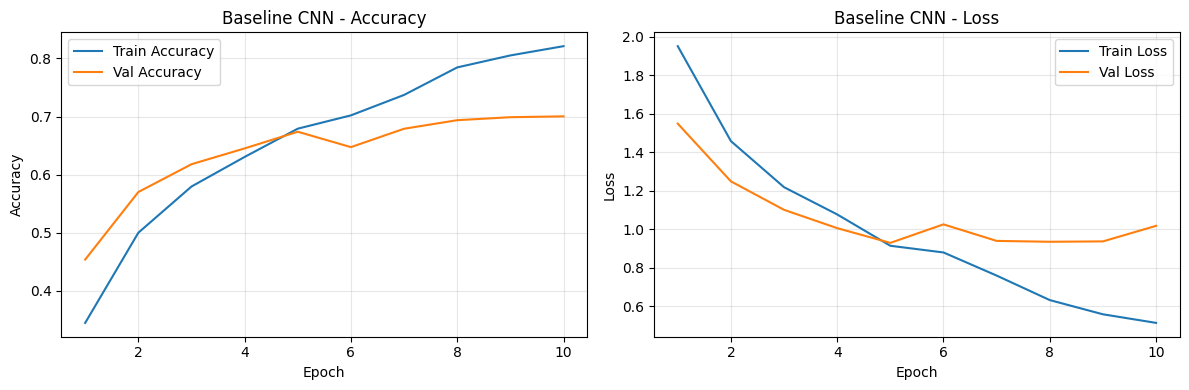

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

baseline_best = tf.keras.models.load_model("best_baseline_cnn.keras")
baseline_loss, baseline_acc = baseline_best.evaluate(test_batches)
print(f"Akurasi Baseline CNN: {baseline_acc * 100:.2f}%")

# Metrik lengkap baseline
y_pred_bl = np.argmax(baseline_best.predict(test_batches), axis=1)
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_batches], axis=0)

print("\nClassification Report Baseline CNN")
print(classification_report(y_true, y_pred_bl, target_names=class_names, zero_division=0))

epochs = range(1, len(history_baseline.history["accuracy"]) + 1)

# Plot training history baseline
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_baseline.history["accuracy"], label="Train Accuracy")
plt.plot(epochs, history_baseline.history["val_accuracy"], label="Val Accuracy")
plt.title("Baseline CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history_baseline.history["loss"], label="Train Loss")
plt.plot(epochs, history_baseline.history["val_loss"], label="Val Loss")
plt.title("Baseline CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Model 2 Penambahan MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_mobilenetv2_transfer():
    inputs = layers.Input(shape=(224, 224, 3))

    x = paper_augmentation(inputs)
    x = preprocess_input(x)

    # Load backbone MobileNetV2 pretrained ImageNet
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Bekukan backbone agar bobot ImageNet tidak berubah pada tahap awal
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Nadam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

mobilenet_model = build_mobilenetv2_transfer()
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,918 (8.68 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training MobileNetV2 dengan Checkpoint dan EarlyStopping

In [ ]:
checkpoint_mobilenet = tf.keras.callbacks.ModelCheckpoint(
    "best_mobilenetv2.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

early_stop_mobilenet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

history_mobilenet = mobilenet_model.fit(
    train_batches,
    validation_data=val_batches,
    epochs=EPOCHS,
    callbacks=[checkpoint_mobilenet, early_stop_mobilenet]
)

Epoch 1/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 62s 127ms/step - accuracy: 0.7242 - loss: 0.9001 - val_accuracy: 0.8785 - val_loss: 0.4155
Epoch 2/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.8621 - loss: 0.4422 - val_accuracy: 0.8940 - val_loss: 0.3328
Epoch 3/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.8818 - loss: 0.3656 - val_accuracy: 0.9094 - val_loss: 0.2959
Epoch 4/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.8969 - loss: 0.3262 - val_accuracy: 0.9006 - val_loss: 0.2907
Epoch 5/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.9030 - loss: 0.3000 - val_accuracy: 0.9109 - val_loss: 0.2745
Epoch 6/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9062 - loss: 0.2895 - val_accuracy: 0.9116 - val_loss: 0.2668
Epoch 7/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9135 - loss: 0.2660 - val_accuracy: 0.9138 - val_loss: 0.2731
Epoch 8/25
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.9149 - loss: 0.2622 -

Evaluasi MobileNetV2 pada Test Set

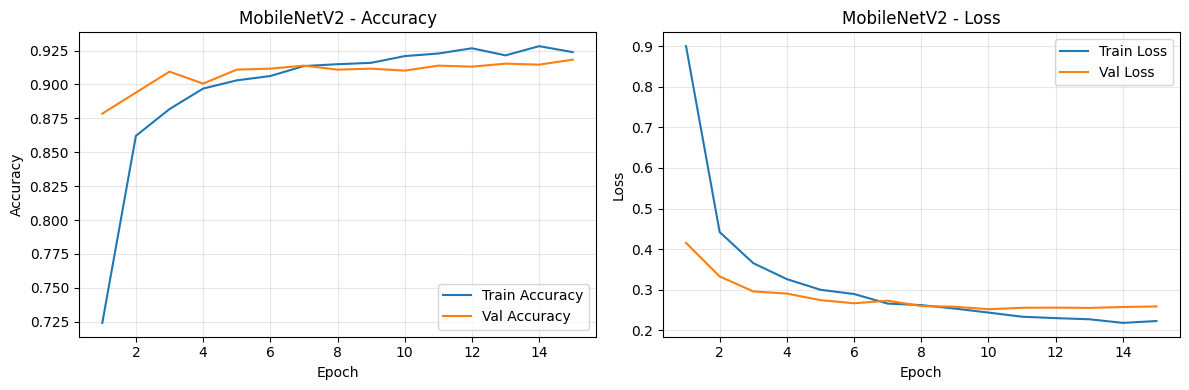

In [ ]:
# Plot training history MobileNetV2
epochs = range(1, len(history_mobilenet.history["accuracy"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_mobilenet.history["accuracy"], label="Train Accuracy")
plt.plot(epochs, history_mobilenet.history["val_accuracy"], label="Val Accuracy")
plt.title("MobileNetV2 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history_mobilenet.history["loss"], label="Train Loss")
plt.plot(epochs, history_mobilenet.history["val_loss"], label="Val Loss")
plt.title("MobileNetV2 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Evaluasi MobileNetV2
mobilenet_best = tf.keras.models.load_model("best_mobilenetv2.keras")
mobilenet_loss, mobilenet_acc = mobilenet_best.evaluate(test_batches)
print(f"Akurasi MobileNetV2 Transfer Learning: {mobilenet_acc * 100:.2f}%")

y_pred_mn = np.argmax(mobilenet_best.predict(test_batches), axis=1)

print("\nClassification Report MobileNetV2")
print(classification_report(y_true, y_pred_mn, target_names=class_names, zero_division=0))

44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 276ms/step - accuracy: 0.9049 - loss: 0.2958
Akurasi MobileNetV2 Transfer Learning: 90.49%
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step

Classification Report MobileNetV2
                  precision    recall  f1-score   support

         astilbe       0.89      0.86      0.88        74
      bellflower       0.84      0.83      0.83        88
black_eyed_susan       0.94      1.00      0.97       100
       calendula       0.78      0.70      0.74       102
california_poppy       0.87      0.84      0.86       103
       carnation       0.84      0.82      0.83        93
    common_daisy       0.87      0.92      0.89        99
       coreopsis       0.86      0.90      0.88       104
       dandelion       0.94      0.97      0.95       105
            iris       0.95      0.97      0.96       105
            rose       0.94      0.94      0.94       100
       sunflower       0.99      0.95      0.97       102
           tulip       0.95      0.96      0.9

#Perbandingan

                    PERBANDINGAN MODEL                    
Metrik                   Baseline CNN      MobileNetV2
----------------------------------------------------------
Accuracy                       68.58%           90.49%
Precision                      69.00%           90.40%
Recall                         68.58%           90.49%
F1-Score                       68.12%           90.40%
----------------------------------------------------------


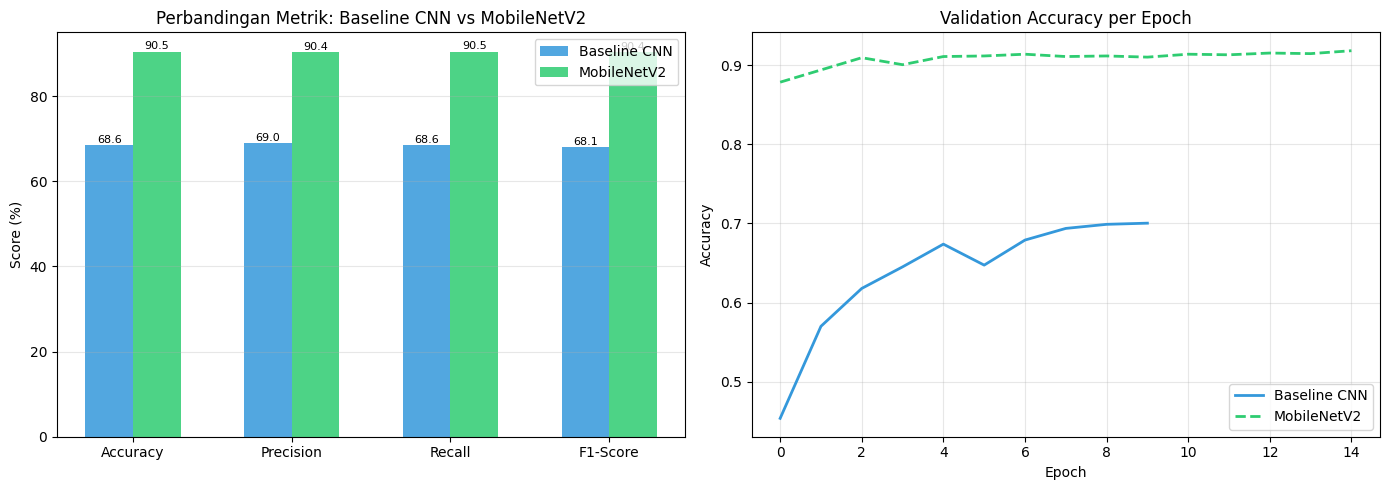

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Hitung semua metrik
f1_bl = f1_score(y_true, y_pred_bl, average="weighted", zero_division=0)
f1_mn = f1_score(y_true, y_pred_mn, average="weighted", zero_division=0)
pr_bl = precision_score(y_true, y_pred_bl, average="weighted", zero_division=0)
pr_mn = precision_score(y_true, y_pred_mn, average="weighted", zero_division=0)
rc_bl = recall_score(y_true, y_pred_bl, average="weighted", zero_division=0)
rc_mn = recall_score(y_true, y_pred_mn, average="weighted", zero_division=0)

# Tabel perbandingan teks
print(f"{'PERBANDINGAN MODEL':^58}")
print("=" * 58)
print(f"{'Metrik':<20} {'Baseline CNN':>16} {'MobileNetV2':>16}")
print("-" * 58)
print(f"{'Accuracy':<20} {baseline_acc*100:>15.2f}% {mobilenet_acc*100:>15.2f}%")
print(f"{'Precision':<20} {pr_bl*100:>15.2f}% {pr_mn*100:>15.2f}%")
print(f"{'Recall':<20} {rc_bl*100:>15.2f}% {rc_mn*100:>15.2f}%")
print(f"{'F1-Score':<20} {f1_bl*100:>15.2f}% {f1_mn*100:>15.2f}%")
print("-" * 58)

# Plot perbandingan metrik
metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores_bl = [baseline_acc, pr_bl, rc_bl, f1_bl]
scores_mn = [mobilenet_acc, pr_mn, rc_mn, f1_mn]

x = np.arange(len(metrics_names))
w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart perbandingan
axes[0].bar(x - w/2, [s*100 for s in scores_bl], w,
            label="Baseline CNN", color="#3498db", alpha=0.85)
axes[0].bar(x + w/2, [s*100 for s in scores_mn], w,
            label="MobileNetV2", color="#2ecc71", alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].set_ylabel("Score (%)")
axes[0].set_title("Perbandingan Metrik: Baseline CNN vs MobileNetV2")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for i, (sb, sm) in enumerate(zip(scores_bl, scores_mn)):
    axes[0].text(i - w/2, sb*100 + 0.5, f"{sb*100:.1f}", ha="center", fontsize=8)
    axes[0].text(i + w/2, sm*100 + 0.5, f"{sm*100:.1f}", ha="center", fontsize=8)

# Val accuracy curve keduanya
axes[1].plot(history_baseline.history["val_accuracy"],
             label="Baseline CNN", color="#3498db", linewidth=2)
axes[1].plot(history_mobilenet.history["val_accuracy"],
             label="MobileNetV2", color="#2ecc71", linewidth=2, linestyle="--")
axes[1].set_title("Validation Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

# Pilih model yang mau dipakai
model_manual = tf.keras.models.load_model("best_mobilenetv2.keras")
#("best_baseline_cnn.keras") kalau mau baseline

def predict_manual_image(image_path, model, class_names, img_size=IMG_SIZE, top_k=3):
    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img)

    # Tambahkan dimensi batch: dari (224,224,3) menjadi (1,224,224,3)
    input_array = np.expand_dims(img_array, axis=0)

    # Prediksi
    probabilities = model.predict(input_array, verbose=0)[0]

    # Ambil kelas dengan probabilitas tertinggi
    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    print("Hasil prediksi")
    print(f"Kelas      : {predicted_class}")
    print(f"Keyakinan  : {confidence*100:.2f}%")

    print(f"\nTop prediksi")
    top_indices = np.argsort(probabilities)[::-1][:top_k]

    for i in top_indices:
        print(f"{class_names[i]:<30} : {probabilities[i]*100:.2f}%")

    return predicted_class, confidence, probabilities

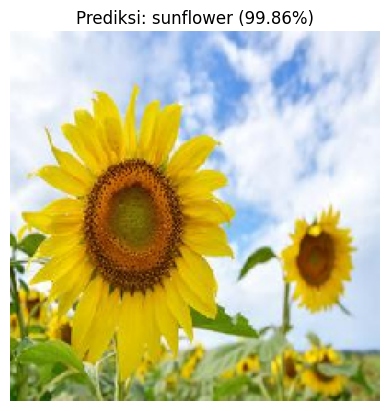

Hasil prediksi
Kelas      : sunflower
Keyakinan  : 99.86%

Top prediksi
sunflower                      : 99.86%
common_daisy                   : 0.08%
calendula                      : 0.05%


In [ ]:
image_path = "/content/Flower/flowers14/val/sunflower/38013640784_60a8f8181d_c.jpg"

predicted_class, confidence, probabilities = predict_manual_image(
    image_path=image_path,
    model=model_manual,
    class_names=class_names
)

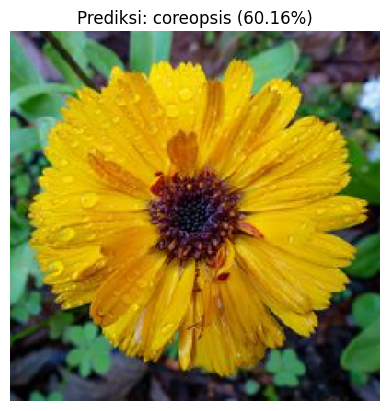

Hasil prediksi
Kelas      : coreopsis
Keyakinan  : 60.16%

Top prediksi
coreopsis                      : 60.16%
calendula                      : 29.04%
common_daisy                   : 3.52%


In [ ]:
image_path = "/content/Flower/flowers14/val/calendula/45993517234_5e4dfdefae_c.jpg"

predicted_class, confidence, probabilities = predict_manual_image(
    image_path=image_path,
    model=model_manual,
    class_names=class_names
)

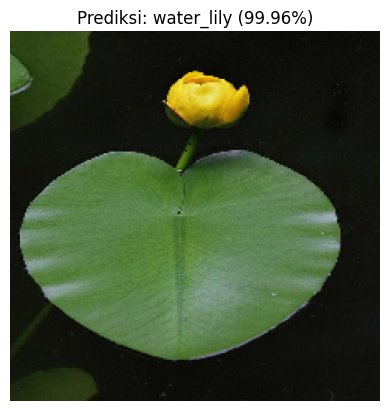

Hasil prediksi
Kelas      : water_lily
Keyakinan  : 99.96%

Top prediksi
water_lily                     : 99.96%
california_poppy               : 0.04%
bellflower                     : 0.00%


In [ ]:
image_path = "/content/Flower/flowers14/val/water_lily/51097519162_2d27f1fe86_c.jpg"

predicted_class, confidence, probabilities = predict_manual_image(
    image_path=image_path,
    model=model_manual,
    class_names=class_names
)